<a href="https://colab.research.google.com/github/DammuNikhitha/AI-ML-Internship-Task-10/blob/main/01_TASK10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 10: KNN – Handwritten Digit Classification




## Step 1: Import Required Libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


## Step 2: Load Dataset and Check Shape


In [8]:
data = pd.read_csv("train.csv")
data = data.fillna(0)
print("Dataset shape:", data.shape)
data.head()

Dataset shape: (42000, 785)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Step 3: Separate Features (X) and Labels (y)


In [9]:
X = data.iloc[:, 1:]
y = data.iloc[:, 0]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (42000, 784)
y shape: (42000,)


## Step 4: Visualize Sample Digit Images


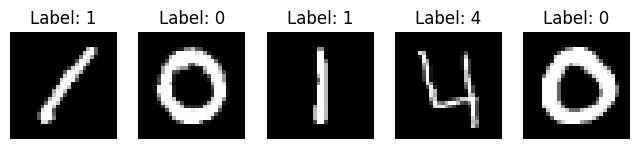

In [10]:
plt.figure(figsize=(8,4))

for i in range(5):
    plt.subplot(1,5,i+1)
    image = X.iloc[i].values.reshape(28,28)
    plt.imshow(image, cmap='gray')
    plt.title(f"Label: {y.iloc[i]}")
    plt.axis('off')

plt.show()

## Step 5: Split Dataset into Training and Testing Sets

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (33600, 784)
Testing samples: (8400, 784)


## Step 6: Feature Scaling using StandardScaler
(KNN is distance-based, so scaling is required)


In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Step 7: Train KNN Model with K = 3 and Evaluate Accuracy


In [13]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy with K=3:", accuracy)

Accuracy with K=3: 0.9421428571428572


## Step 8: Try Different K Values (3, 5, 7, 9)


In [14]:
k_values = [3,5,7,9]
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred_k = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred_k)
    accuracies.append(acc)
    print(f"K={k}, Accuracy={acc}")

K=3, Accuracy=0.9421428571428572
K=5, Accuracy=0.9391666666666667
K=7, Accuracy=0.9392857142857143
K=9, Accuracy=0.9354761904761905


## Step 9: Plot Accuracy vs K


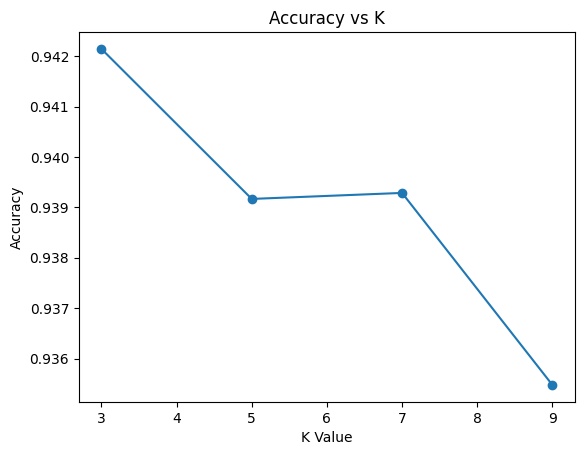

In [15]:
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.show()

## Step 10: Generate Confusion Matrix


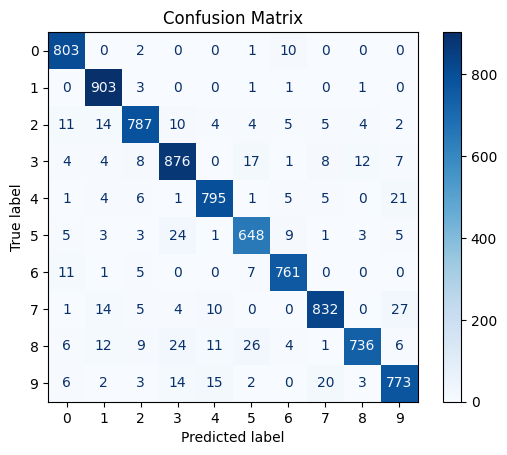

In [16]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

## Step 11: Display Sample Test Images with Predicted Labels


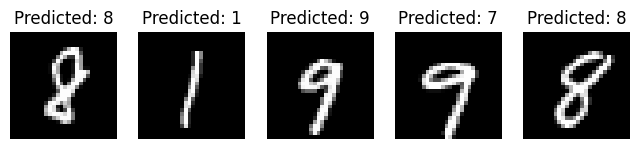

In [17]:
plt.figure(figsize=(8,4))

for i in range(5):
    plt.subplot(1,5,i+1)
    image = X_test.iloc[i].values.reshape(28,28)
    plt.imshow(image, cmap='gray')
    plt.title(f"Predicted: {y_pred[i]}")
    plt.axis('off')

plt.show()